# Imports and Data Loading

In [46]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import reverse_geocoder as rg
from xgboost import XGBRegressor
from scipy.stats import spearmanr
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, PredefinedSplit, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [92]:
# load data
path = "../data/sat_nutrients_weather.csv"
df = pd.read_csv(path)

# Creating Spatial Groups

In [93]:
# create rounded latitude and longitude cols
df["lon_binned"] = df["longitude"].round(0)
df["lat_binned"] = df["latitude"].round(0)

# create day of year col
df["caml_sample_date"] = pd.to_datetime(df["caml_sample_date"])
df['day_of_yr'] = df['caml_sample_date'].dt.dayofyear

# Estimating Model Potential and Tuning Hyperparameters with Spatial Cross-Validation

## Creating and Visualizing Folds

In [12]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "caml_sample_date", "is_s2"]
X = df.drop(columns=drop_cols)
y = df["log_abundance"]

In [13]:
# create spatial groups
groups = (X["lat_binned"].astype(str) + "_" + X["lon_binned"].astype(str))

# bin y to create levels of log abundance values for stratified k folds
y_binned = pd.qcut(y, q=5, labels=False)

# set up splitter, create folds, assign each row to its fold index, create fold column for visualization
sgkf = StratifiedGroupKFold(n_splits=5)
fold_map = np.full(len(X), -1)
X["fold"] = -1
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y_binned, groups=groups)):
    fold_map[test_idx] = i
    X.loc[test_idx, "fold"] = i

# drop exact latitude and longitude 
X_clean = X.drop(columns=["latitude", "longitude", "lat_binned", "lon_binned", "fold"])

# create a predefined split so the same folds are used in every search
ps = PredefinedSplit(test_fold=fold_map)

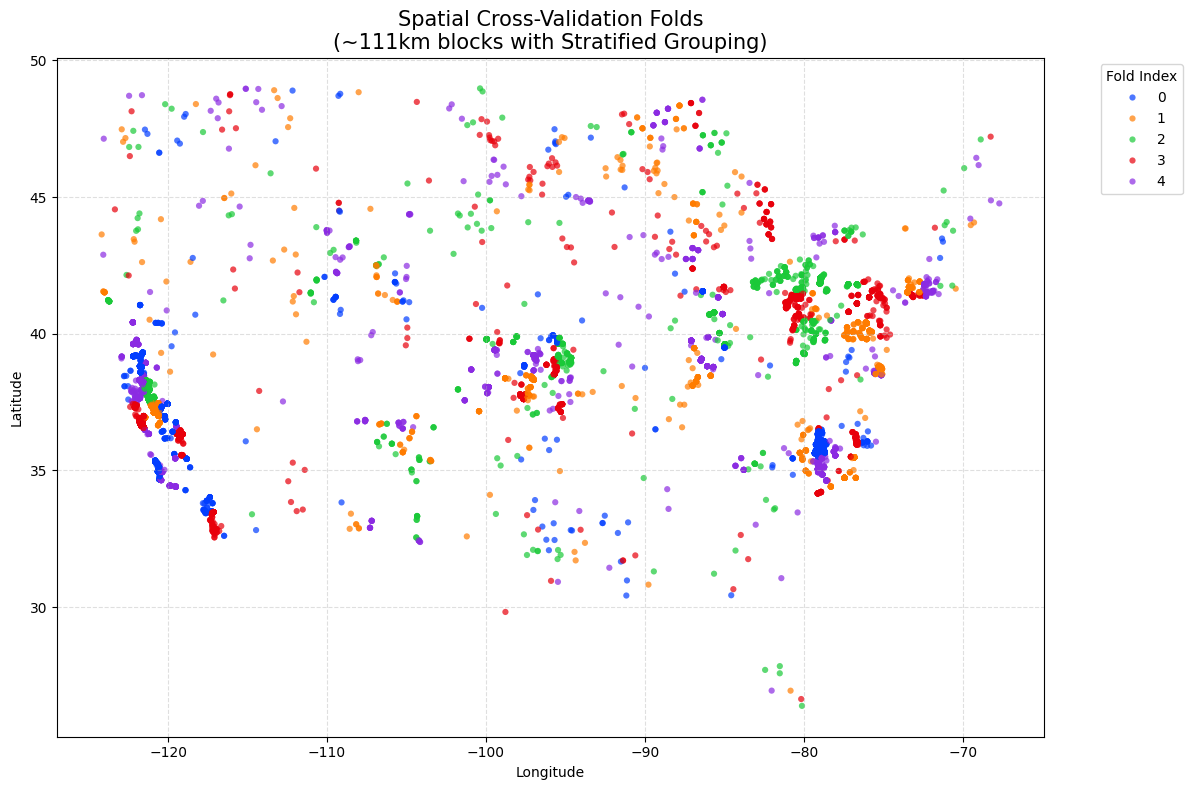

In [14]:
# visualization of folds
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=X, x="longitude", y="latitude", hue="fold", palette="bright", s=20, alpha=0.7, edgecolor="none")

plt.title("Spatial Cross-Validation Folds\n(~111km blocks with Stratified Grouping)", fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fold Index', bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## XGBoost

### Hyperparameter Tuning

In [15]:
# create grid of parameters to test
param_grid_xgb = {
    'max_depth': [3, 4, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'n_estimators': [100, 500, 1000],
}

In [16]:
# create and run search
search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid_xgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_xgb.fit(X_clean, y)

# display results
xgb_params = search_xgb.best_params_
print(f"best score: {search_xgb.best_score_}")
print(f"best parameters: {xgb_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best score: 0.5830139191772694
best parameters: {'subsample': 0.9, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


### Results Analysis on Optimal Model

In [17]:
# display best model's scores for all folds
results_df = pd.DataFrame(search_xgb.cv_results_)

best_model_idx = search_xgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] for i in range(search_xgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.55381373 0.57986163 0.70216295 0.62540559 0.4538257 ]


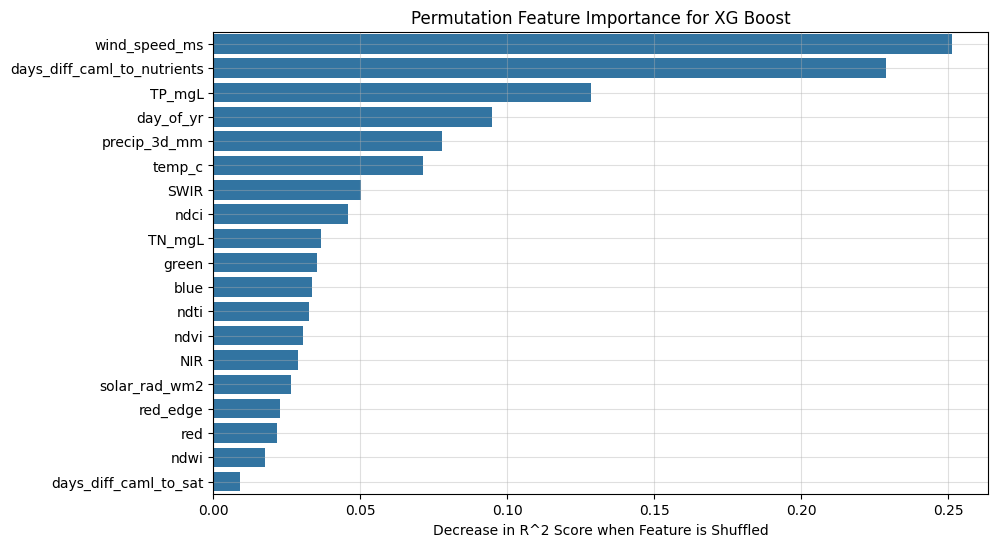

In [18]:
# feature importance plot for best model
xgb = search_xgb.best_estimator_

result = permutation_importance(
    xgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for XG Boost")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [19]:
# display rmse and mae for each fold
xgb_rmse = []
xgb_mae = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = xgb.predict(X_test)
    preds_transformed = (10 ** preds) - 1
        
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    xgb_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(xgb_rmse)}")
print(f"best model's average rmse: {np.mean(xgb_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(xgb_mae)}")

best model's rmse for each fold: [0.38961518 0.41832844 0.3723809  0.38721824 0.49971765]
best model's average rmse: 0.4134520816627257
best model's median absolute error for each fold (transformed back into cells/mL): [ 24.76190307 444.00048985 466.58229896 296.45579635 253.29696841]


## Random Forest
### Hyperparameter Tuning

In [20]:
# create grid of parameters to test
param_grid_rf = {
    'n_estimators': [100, 200, 500],        
    'max_depth': [4, 6, 8, 10],            
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [2, 4, 8],         
    'max_features': ['sqrt', 'log2'],      
    'bootstrap': [True]                 
}

In [21]:
# create and run search
search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_rf.fit(X_clean, y)

# display results
rf_params = search_rf.best_params_
print(f"best Score: {search_rf.best_score_}")
print(f"best Params: {rf_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.5488234174832579
best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}


### Results Analysis on Optimal Model

In [22]:
results_df = pd.DataFrame(search_rf.cv_results_)

best_model_idx = search_rf.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] 
               for i in range(search_rf.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.53420634 0.53094136 0.67091254 0.59858304 0.4094738 ]


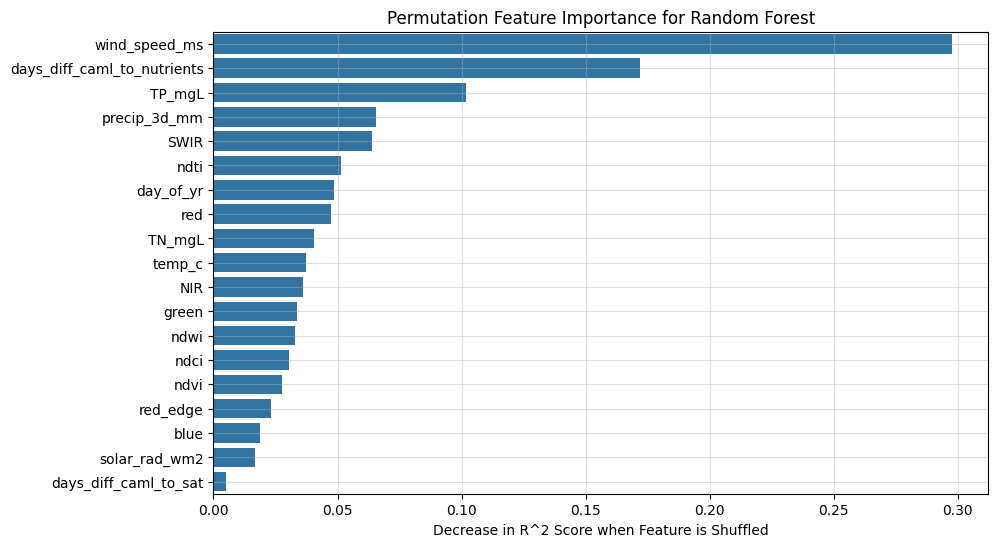

In [23]:
# feature importance plot for best model
rf = search_rf.best_estimator_

result = permutation_importance(
    rf, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for Random Forest")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [24]:
rf_rmse = []
rf_mae = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = rf.predict(X_test)
    preds_transformed = (10 ** preds) - 1
        
    rf_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    rf_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(rf_rmse)}")
print(f"best model's average rmse: {np.mean(rf_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(rf_mae)}")

best model's rmse for each fold: [0.54625658 0.61729932 0.53309697 0.58067487 0.71426704]
best model's average rmse: 0.598318957044062
best model's median absolute error for each fold (transformed back into cells/mL): [ 30.85714717 329.48437449 323.73369642 201.99188502 205.79108487]


## Histogram Gradient Boosting Regressor
### Hyperparameter Tuning

In [25]:
# create grid of parameters to try
param_grid_hgb = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_regularization': [0, 1, 10, 100]
}

In [26]:
# create and run search
search_hgb = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_hgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_hgb.fit(X_clean, y)

# display results
hgb_params = search_hgb.best_params_
print(f"best Score: {search_hgb.best_score_}")
print(f"best Params: {hgb_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.5751301295085808
best Params: {'max_iter': 300, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 10}


### Results Analysis on Optimal Model

In [27]:
results_df = pd.DataFrame(search_hgb.cv_results_)

best_model_idx = search_hgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] for i in range(search_hgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.55587871 0.58588784 0.6887234  0.63047634 0.41468436]


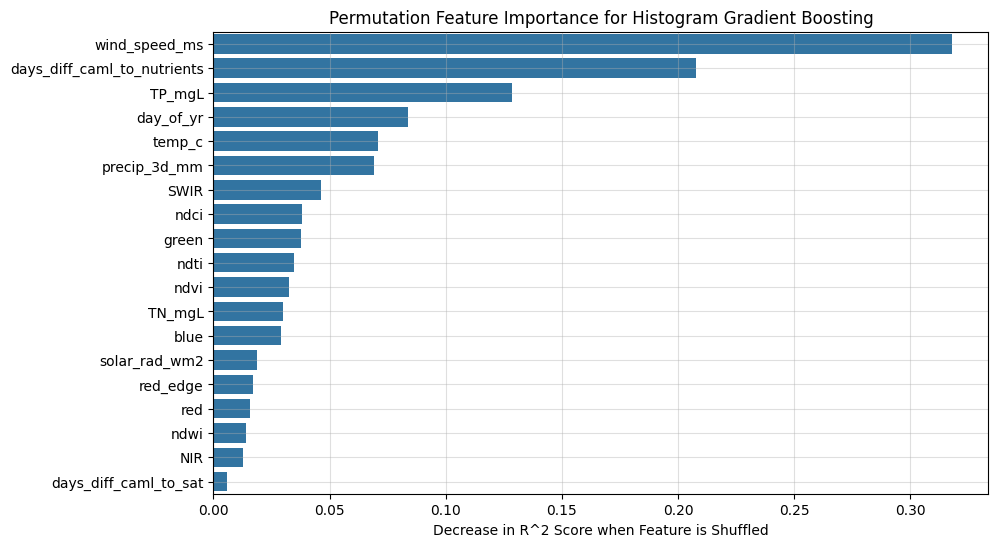

In [28]:
# feature importance plot for best model
hgb = search_hgb.best_estimator_

result = permutation_importance(
    hgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title('Permutation Feature Importance for Histogram Gradient Boosting')
plt.xlabel('Decrease in R^2 Score when Feature is Shuffled')
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [29]:
hgb_rmse = []
hgb_mae = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = hgb.predict(X_test)
    preds_transformed = (10 ** preds) - 1
        
    hgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    hgb_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(hgb_rmse)}")
print(f"best model's average rmse: {np.mean(hgb_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(hgb_mae)}")

best model's rmse for each fold: [0.5060222  0.53400025 0.47720071 0.50725938 0.64260487]
best model's average rmse: 0.5334174817401058
best model's median absolute error for each fold (transformed back into cells/mL): [ 25.54654453 363.67732742 496.30276382 258.21588407 234.26500759]


# Evaluating Generalization with In-Distribution Test Sets

In [95]:
# adding a state column to remove a state for testing
coords = list(zip(df['latitude'], df['longitude']))
results = rg.search(coords)

df['state'] = [res['admin1'] for res in results]

In [88]:
print(df["state"].value_counts())

state
California        3577
North Carolina    1880
Kansas             822
Pennsylvania       652
Indiana            398
Connecticut        184
Delaware           166
Ohio               147
New York           126
Michigan           119
New Mexico         108
Wyoming             97
Ontario             78
Minnesota           53
Wisconsin           50
West Virginia       46
Texas               29
South Dakota        29
Washington          24
North Dakota        24
Idaho               24
Montana             19
Oregon              18
South Carolina      18
Maryland            16
Nebraska            15
Colorado            15
Utah                15
Virginia            14
New Jersey          13
Missouri            12
Oklahoma            11
Maine               11
Nevada              10
Georgia             10
Florida              9
Mississippi          9
Illinois             8
Iowa                 8
New Hampshire        7
Arizona              7
Louisiana            7
Kentucky             6
Massa

## Pacific Northwest

In [105]:
holdout_states_pnw = ["Washington", "Oregon", "Idaho", "Montana", "Wyoming"]
df_test = df[df['state'].isin(holdout_states_pnw)].copy()
df_train = df[~df['state'].isin(holdout_states_pnw)].copy()

In [106]:
df_test.shape

(182, 30)

In [108]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "caml_sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_pnw = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_pnw = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_pnw = df_test["log_abundance"].reset_index(drop=True)
y_train_pnw = df_train["log_abundance"].reset_index(drop=True)

In [109]:
results_pnw = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

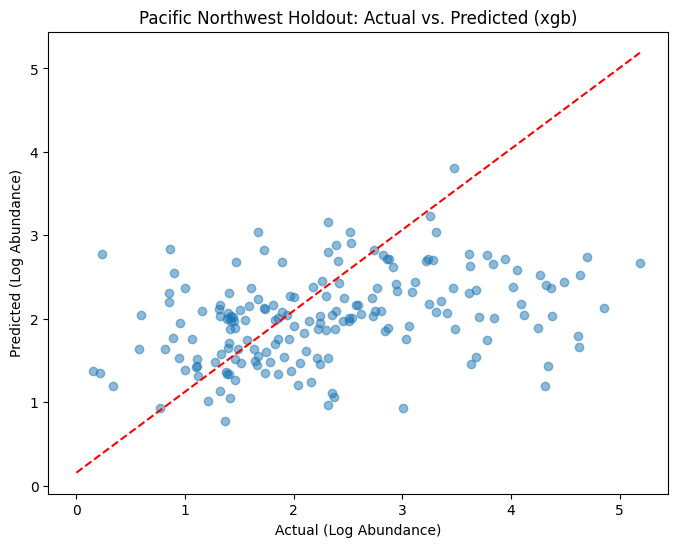

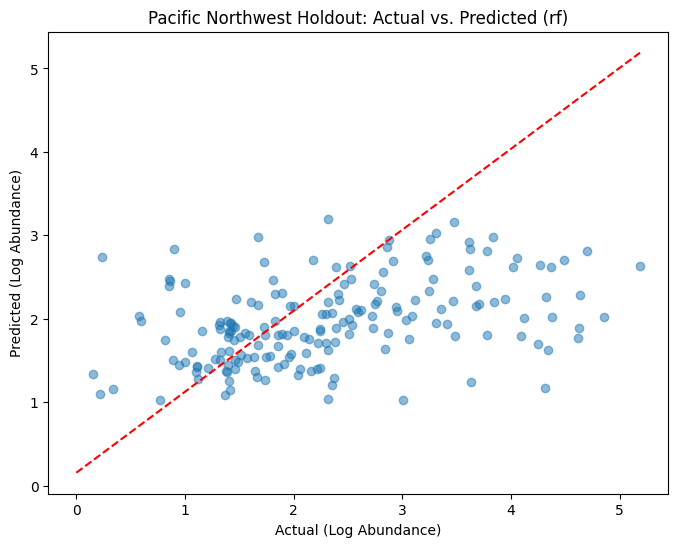

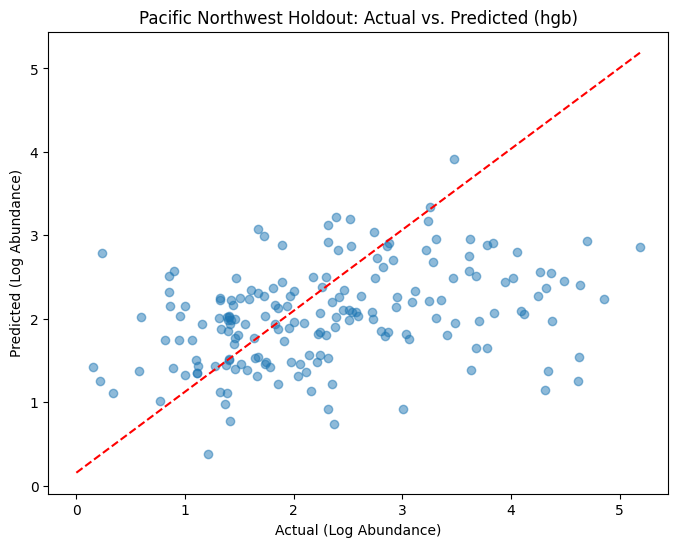

    r squared      rmse         mae       rho
xgb  0.035159  1.066771  102.856368  0.398432
rf   0.063612  1.050924   78.715966  0.439569
hgb  0.022096  1.073968  102.743912  0.389938


In [110]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_pnw, y_train_pnw)

    preds = model.predict(X_test_pnw)
    preds_transformed = (10 ** preds) - 1

    results_pnw.loc[name, "r squared"] = model.score(X_test_pnw, y_test_pnw)
    results_pnw.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_pnw, preds))
    results_pnw.loc[name, "mae"] = np.median(np.abs(y_test_pnw - preds_transformed))
    results_pnw.loc[name, "rho"] = spearmanr(y_test_pnw, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_pnw, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_pnw.max()], [y_test_pnw.min(), y_test_pnw.max()], 'r--')
    plt.title(f'Pacific Northwest Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_pnw)


## Midwest

In [111]:
holdout_states_mw = ["Ohio", "Indiana", "Michigan", "Pennsylvania"]
df_test = df[df['state'].isin(holdout_states_mw)].copy()
df_train = df[~df['state'].isin(holdout_states_mw)].copy()

In [112]:
df_test.shape

(1316, 30)

In [113]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "caml_sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_mw = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_mw = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_mw = df_test["log_abundance"].reset_index(drop=True)
y_train_mw = df_train["log_abundance"].reset_index(drop=True)

In [114]:
results_mw = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

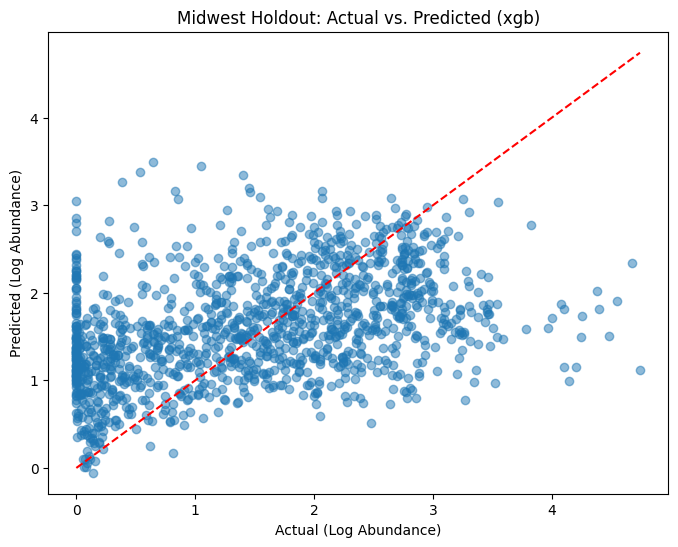

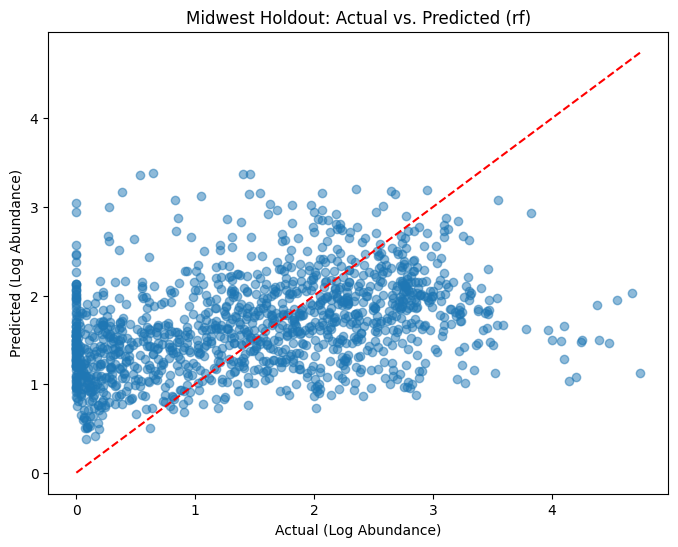

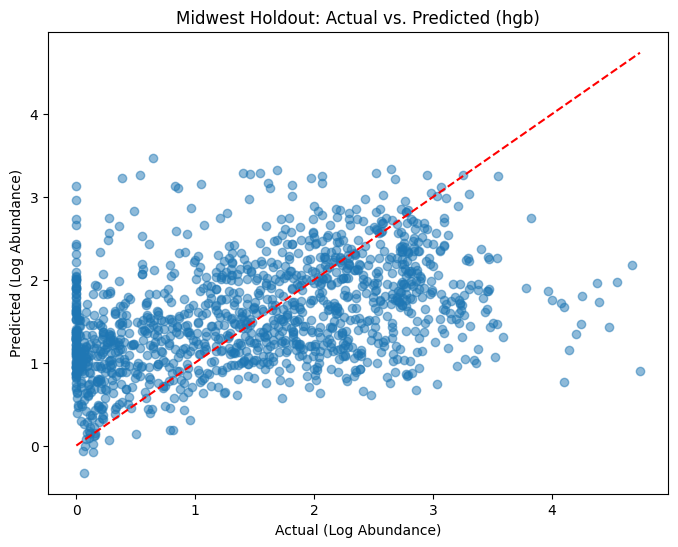

    r squared      rmse        mae       rho
xgb  0.140463  0.983365  32.750074  0.442364
rf   0.112028  0.999498  39.706106  0.421769
hgb  0.161065  0.971508  29.130219  0.456979


In [115]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_mw, y_train_mw)

    preds = model.predict(X_test_mw)
    preds_transformed = (10 ** preds) - 1

    results_mw.loc[name, "r squared"] = model.score(X_test_mw, y_test_mw)
    results_mw.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_mw, preds))
    results_mw.loc[name, "mae"] = np.median(np.abs(y_test_mw - preds_transformed))
    results_mw.loc[name, "rho"] = spearmanr(y_test_mw, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_mw, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_mw.max()], [y_test_mw.min(), y_test_mw.max()], 'r--')
    plt.title(f'Midwest Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_mw)

## Northeast

In [ ]:
holdout_states_ne = ["New York", "Connecticut", "Delaware", "Pennsylvania"]
df_test = df[df['state'].isin(holdout_states_ne)].copy()
df_train = df[~df['state'].isin(holdout_states_ne)].copy()

In [120]:
df_test.shape

(1128, 30)

In [117]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "caml_sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_ne = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_ne = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_ne = df_test["log_abundance"].reset_index(drop=True)
y_train_ne = df_train["log_abundance"].reset_index(drop=True)

In [118]:
results_ne = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

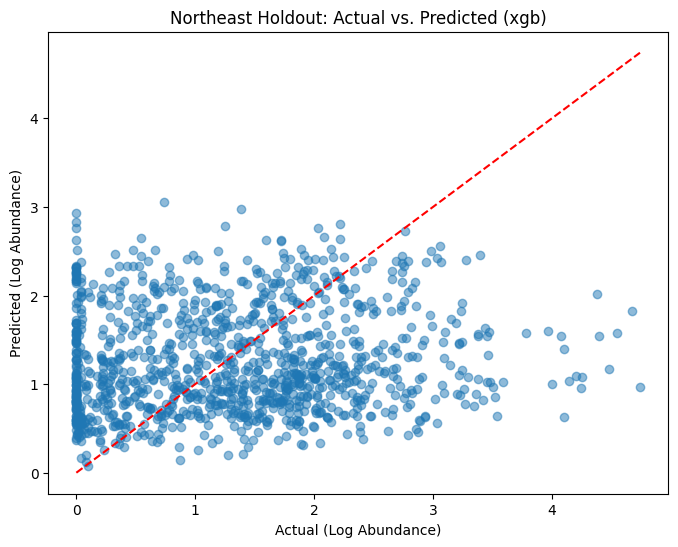

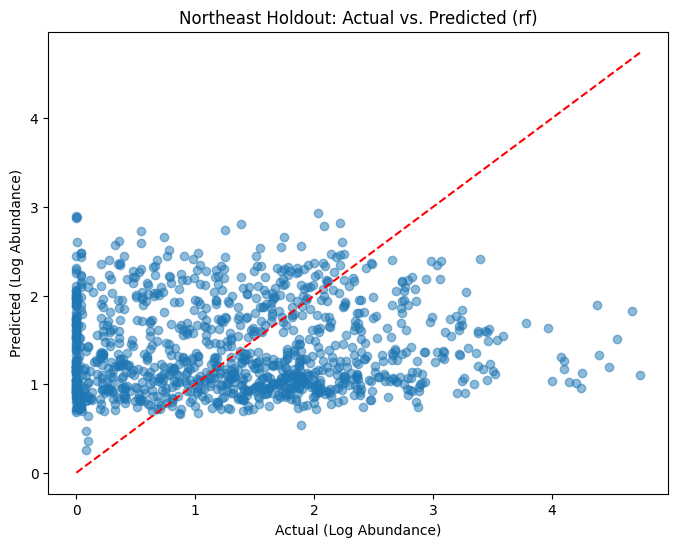

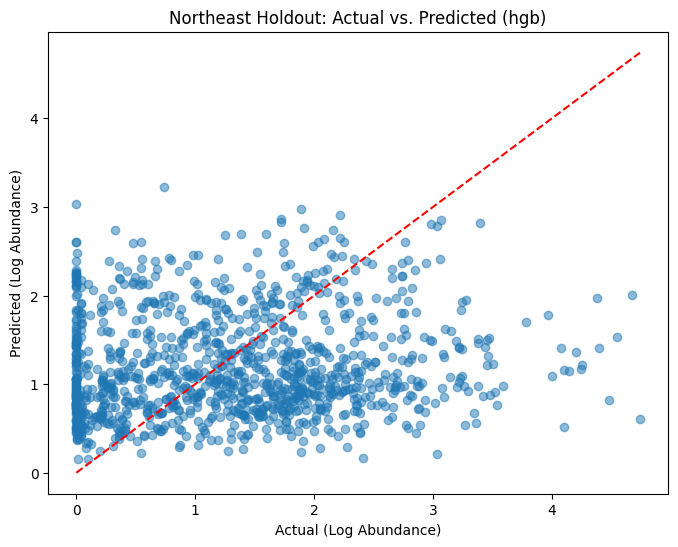

    r squared      rmse        mae       rho
xgb -0.240639  1.099227  10.966471  0.110434
rf  -0.221202  1.090582  15.167381  0.061691
hgb -0.242103  1.099875   9.550261  0.105244


In [119]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_ne, y_train_ne)

    preds = model.predict(X_test_ne)
    preds_transformed = (10 ** preds) - 1

    results_ne.loc[name, "r squared"] = model.score(X_test_ne, y_test_ne)
    results_ne.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_ne, preds))
    results_ne.loc[name, "mae"] = np.median(np.abs(y_test_ne - preds_transformed))
    results_ne.loc[name, "rho"] = spearmanr(y_test_ne, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_ne, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_ne.max()], [y_test_ne.min(), y_test_ne.max()], 'r--')
    plt.title(f'Northeast Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_ne)